<div style="background:linear-gradient(135deg,#022c22 0%,#047857 55%,#10b981 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#d1fae5;font-weight:700;text-transform:uppercase">Chapter 103 · Regularization Case Study</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Predicting Medical Charges</div>
  <div style="font-size:15px;color:#f0fdf4;max-width:740px;line-height:1.6">A many-feature regression project in 12 steps: clean and encode a messy insurance file, expose multicollinearity with VIF, and use ridge, lasso, and elastic net with cross-validation to select the drivers and predict cost, every table and chart explained.</div>
  <div style="margin-top:16px;font-size:13px;color:#d1fae5">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Predicting Medical Charges: a regularization case study
The final capstone, and the one about **many predictors**. With 15 features, some redundant, some pure noise, the star technique is **regularization** (ridge, lasso, elastic net), which selects the signal and tames multicollinearity automatically. Same 12-step method, on a messy insurance file, library-first with `pandas`, `seaborn`, `statsmodels`, and `scikit-learn`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, regplots, pairplots)
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
ORG="#059669"; DEEP="#047857"; LIGHT="#6ee7b7"; EM="#059669"; EMDEEP="#047857"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV, lasso_path
from sklearn.model_selection import cross_val_score
pd.set_option('display.max_columns', 40)

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 1 &#183; DEFINE THE OBJECTIVE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">What drives a patient's medical cost?</div>
<div style="color:#4a5578;margin-top:6px">Predict charges, and find the levers, from many candidate features.</div>
</div>

**Objective.** Predict a patient's annual **medical charges** and identify which factors drive cost, for an insurer setting premiums or a health program targeting interventions.

**The challenge.** We have **15 candidate features**, several of which overlap (height, weight, and BMI all measure body size) or are pure noise. Throwing them all into ordinary regression gives unstable, hard-to-read coefficients. The job is to let the data tell us which features matter, that is what **regularization** does.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 2 &#183; COLLECT THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">An insurance claims export</div>
<div style="color:#4a5578;margin-top:6px">A CSV; the same reader menu applies to any source.</div>
</div>

In [3]:
try: raw = pd.read_csv('../../data/medical_charges.csv')
except FileNotFoundError: raw = pd.read_csv(BASE + 'medical_charges.csv')
print(raw.shape); raw.head(4)

(1018, 17)


,patient_id,age,sex,height_cm,weight_kg,bmi,children,smoker,exercise_hours_wk,diet_score,blood_pressure,cholesterol,region,income_k,noise_a,noise_b,charges
0,P5201,24,Female,174.5,88.9,29.2,4,no,1.7,6,105,205,southwest,36,43.6,37,8288.11
1,P5160,43,M,173.7,63.8,21.1,3,Yes,7.0,9,120,195,SOUTHEAST,54,43.7,31,46593.44
2,P5843,42,M,178.5,130.0,40.8,1,yes,0.9,10,146,242,southwest,51,51.4,91,84317.58
3,P5356,44,Male,169.8,77.5,26.9,5,No,0.8,4,126,190,Southwest,109,39.7,67,11342.60


<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 3 &#183; INSPECT THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Meet 15 features and their problems</div>
<div style="color:#4a5578;margin-top:6px">Types, spellings, and missingness.</div>
</div>

In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1018 entries, 0 to 1017
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         1018 non-null   str    
 1   age                1018 non-null   int64  
 2   sex                1018 non-null   str    
 3   height_cm          1018 non-null   float64
 4   weight_kg          1018 non-null   float64
 5   bmi                994 non-null    float64
 6   children           1018 non-null   int64  
 7   smoker             1018 non-null   str    
 8   exercise_hours_wk  1018 non-null   float64
 9   diet_score         1018 non-null   int64  
 10  blood_pressure     1018 non-null   int64  
 11  cholesterol        1018 non-null   int64  
 12  region             1018 non-null   str    
 13  income_k           1018 non-null   int64  
 14  noise_a            1018 non-null   float64
 15  noise_b            1018 non-null   int64  
 16  charges            1012 non-null   

In [5]:
print('smoker  :', raw.smoker.value_counts().to_dict())
print('sex     :', raw.sex.value_counts().to_dict())
print('region  :', raw.region.unique()[:8])
print('bmi dtype:', raw.bmi.dtype, '| duplicate ids:', raw.patient_id.duplicated().sum())
print('missing :', raw.isna().sum()[lambda s: s>0].to_dict())

smoker  : {'no': 575, 'No': 134, 'yes': 133, 'N': 70, 'Yes': 37, '0': 35, 'Y': 22, '1': 12}
sex     : {'Female': 483, 'Male': 420, 'M': 64, 'F': 51}
region  : <StringArray>
['southwest', 'SOUTHEAST', 'Southwest', 'southeast', 'northwest', 'northeast',
 'NORTHWEST', 'SOUTHWEST']
Length: 8, dtype: str
bmi dtype: float64 | duplicate ids: 18
missing : {'bmi': 24, 'charges': 6}


The familiar mess: `smoker`, `sex`, and `region` in mixed spellings, `bmi` stored as text with some blanks, 18 duplicate patients, and a few rows with no `charges`. And notice `height_cm`, `weight_kg`, and `bmi` are three views of the same thing, a multicollinearity trap we will confirm in step 7.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 4 &#183; CLEAN THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Standardize, dedupe, and rebuild BMI</div>
<div style="color:#4a5578;margin-top:6px">Recompute missing BMI from weight and height.</div>
</div>

In [6]:
df = raw.dropna(subset=['charges']).drop_duplicates(subset='patient_id').copy()
df['charges'] = df['charges'].astype(float)
df['sex'] = df['sex'].str.strip().str.upper().map({'MALE':'Male','M':'Male','FEMALE':'Female','F':'Female'})
df['smoker'] = df['smoker'].astype(str).str.strip().str.upper().map({'YES':1,'Y':1,'1':1,'NO':0,'N':0,'0':0})
df['region'] = df['region'].astype(str).str.strip().str.lower()
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df['bmi'] = df['bmi'].fillna(df['weight_kg'] / (df['height_cm']/100)**2)   # BMI = weight / height^2
print(f'rows {len(raw)} -> {len(df)} (dropped 6 missing-target + 18 duplicates); smoker rate {df.smoker.mean():.0%}')

rows 1018 -> 994 (dropped 6 missing-target + 18 duplicates); smoker rate 20%


<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 5 &#183; VISUALIZE THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Charges, and the one variable that splits them</div>
<div style="color:#4a5578;margin-top:6px">Distribution and the smoker effect.</div>
</div>

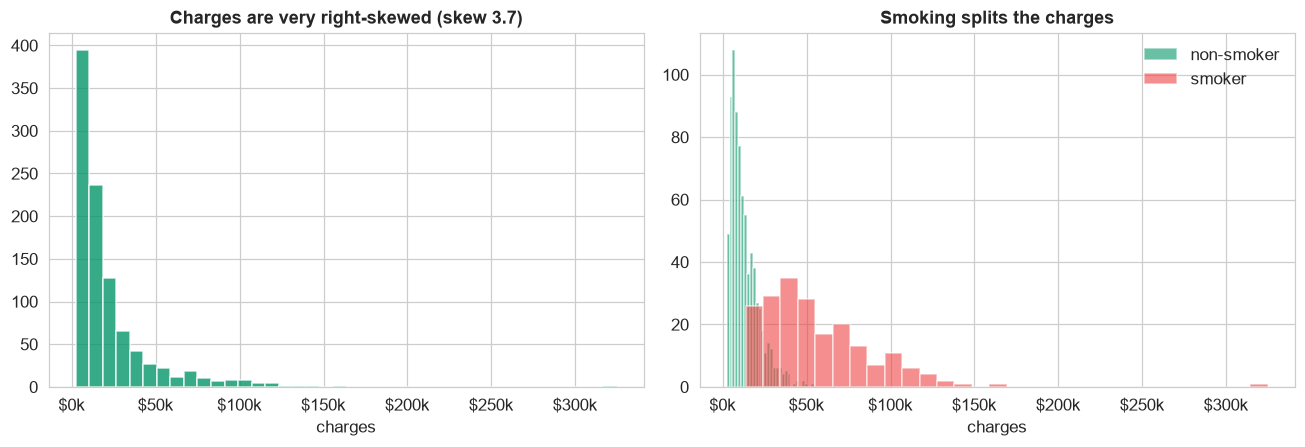

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12,4.2))
ax[0].hist(df.charges, bins=40, color=EM, alpha=0.8); ax[0].set(title=f'Charges are very right-skewed (skew {df.charges.skew():.1f})', xlabel='charges')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
for s,c,lab in [(0,EM,'non-smoker'),(1,RED,'smoker')]:
    ax[1].hist(df[df.smoker==s].charges, bins=30, color=c, alpha=0.6, label=lab)
ax[1].set(title='Smoking splits the charges', xlabel='charges'); ax[1].legend()
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
plt.tight_layout(); plt.show()

Charges are dramatically right-skewed, a few very expensive patients, so we will model **log(charges)**. And one feature stands out already: **smokers form a separate, much more expensive cluster**. Expect it to dominate the model.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 6 &#183; TRANSFORM FEATURES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Log the target, encode, and standardize</div>
<div style="color:#4a5578;margin-top:6px">Standardizing is essential for regularization to be fair.</div>
</div>

In [8]:
df['log_charges'] = np.log(df['charges'])
feats = ['age','bmi','height_cm','weight_kg','children','smoker','exercise_hours_wk','diet_score',
         'blood_pressure','cholesterol','income_k','noise_a','noise_b']
X = pd.get_dummies(df[feats].join(df['region']), columns=['region'], drop_first=True).astype(float)
Xs = StandardScaler().fit_transform(X); y = df['log_charges'].values
print(f'log fixed the skew: {df.charges.skew():.1f} -> {df.log_charges.skew():.2f}')
print(f'{X.shape[1]} model features after encoding')

log fixed the skew: 3.7 -> 0.44
16 model features after encoding


We model **log(charges)** (the skew drops from ~3.7 to ~0.4), one-hot encode `region`, and, crucially, **standardize every feature** to the same scale. Standardizing matters here because a penalty that shrinks coefficients must treat a feature measured in dollars and one measured in years even-handedly.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 7 &#183; ANALYZE PATTERNS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Confirm the multicollinearity</div>
<div style="color:#4a5578;margin-top:6px">VIF exposes the redundant body-size trio.</div>
</div>

In [9]:
Xc = sm.add_constant(df[['weight_kg','bmi','height_cm','age','blood_pressure','cholesterol']].astype(float))
vif = pd.Series({c: variance_inflation_factor(Xc.values, i) for i,c in enumerate(Xc.columns)}).drop('const')
print('VIF:'); print(vif.round(1).to_string())
print('\nweight/height/BMI have enormous VIF -> they are redundant (BMI is built from the other two).')

VIF:
weight_kg         97.2
bmi               70.8
height_cm         23.6
age                1.1
blood_pressure     1.0
cholesterol        1.0

weight/height/BMI have enormous VIF -> they are redundant (BMI is built from the other two).


The variance inflation factors are damning: **weight, BMI, and height all have VIF far above 10**, because BMI is literally computed from weight and height. In ordinary regression this makes their coefficients wild and untrustworthy. Regularization will resolve it automatically, no manual dropping required.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 8 &#183; BUILD THE MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Fit OLS, ridge, lasso, and elastic net</div>
<div style="color:#4a5578;margin-top:6px">Same features, four penalties, one comparison.</div>
</div>

In [10]:
ols = LinearRegression().fit(Xs, y)
ridge = RidgeCV(alphas=np.logspace(-3,3,50)).fit(Xs, y)
lasso = LassoCV(cv=5, random_state=0).fit(Xs, y)
enet = ElasticNetCV(l1_ratio=[.2,.5,.8,1.0], cv=5, random_state=0).fit(Xs, y)
print(f'R2   OLS={ols.score(Xs,y):.3f}  Ridge={ridge.score(Xs,y):.3f}  Lasso={lasso.score(Xs,y):.3f}  ElasticNet={enet.score(Xs,y):.3f}')
print(f'lasso alpha={lasso.alpha_:.4f}   elastic-net l1_ratio={enet.l1_ratio_}')

R2   OLS=0.866  Ridge=0.866  Lasso=0.865  ElasticNet=0.865
lasso alpha=0.0087   elastic-net l1_ratio=1.0


All four fit about equally well (R-squared ~0.87), the penalty costs almost no accuracy. The difference is in *which features survive*, which we read next.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 9 &#183; VALIDATE THE MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Feature selection, the path, and honest accuracy</div>
<div style="color:#4a5578;margin-top:6px">Lasso zeros the redundant and noise features; cross-validation confirms the fit.</div>
</div>

In [11]:
coef = pd.Series(lasso.coef_, index=X.columns)
print('KEPT  :', [c for c in X.columns if abs(coef[c])>1e-6])
print('ZEROED:', [c for c in X.columns if abs(coef[c])<1e-6])
cv = cross_val_score(LassoCV(cv=5, random_state=0), Xs, y, cv=5)
print(f'\n5-fold cross-validated R2 = {cv.mean():.3f}  (vs in-sample {lasso.score(Xs,y):.3f}) -> not overfit')

KEPT  : ['age', 'bmi', 'children', 'smoker', 'exercise_hours_wk', 'blood_pressure', 'cholesterol', 'income_k', 'region_northwest', 'region_southwest']
ZEROED: ['height_cm', 'weight_kg', 'diet_score', 'noise_a', 'noise_b', 'region_southeast']

5-fold cross-validated R2 = 0.860  (vs in-sample 0.865) -> not overfit


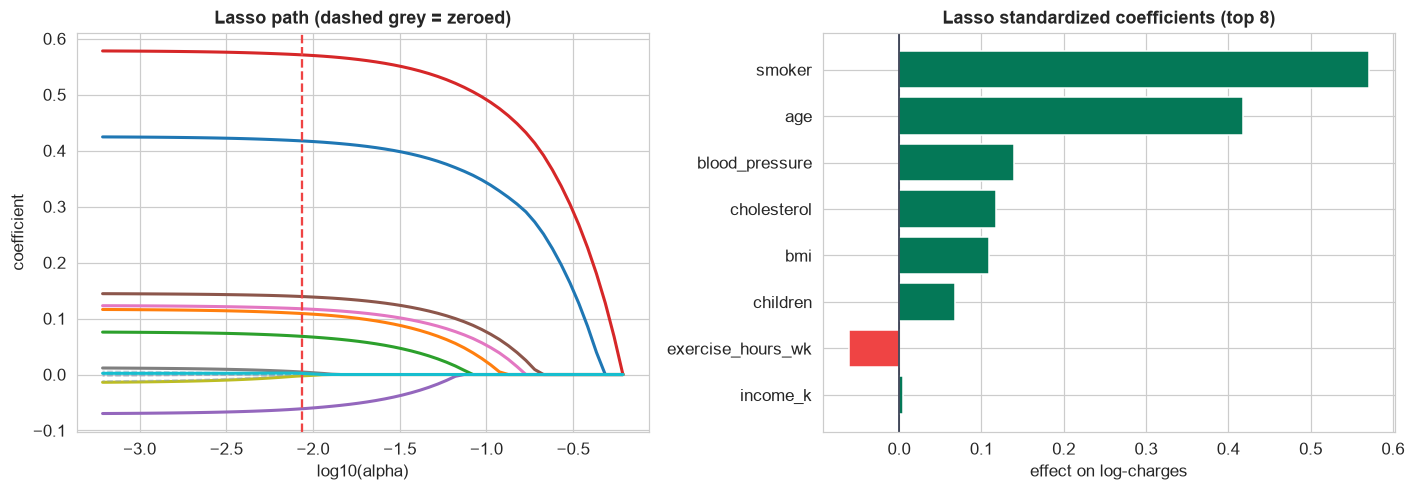

In [12]:
# the regularization path + standardized coefficients
alphas, coefs, _ = lasso_path(Xs, y - y.mean(), n_alphas=60)
fig, ax = plt.subplots(1, 2, figsize=(13,4.6))
for i, f in enumerate(X.columns):
    real = abs(coef[f])>1e-6
    ax[0].plot(np.log10(alphas), coefs[i], lw=2 if real else 1, ls='-' if real else '--', color=None if real else GREY, alpha=1 if real else 0.5)
ax[0].axvline(np.log10(lasso.alpha_), color=RED, ls='--'); ax[0].set(title='Lasso path (dashed grey = zeroed)', xlabel='log10(alpha)', ylabel='coefficient')
cs = coef.reindex(coef.abs().sort_values(ascending=False).index).head(8)[::-1]
ax[1].barh(range(len(cs)), cs.values, color=[DEEP if v>0 else RED for v in cs.values])
ax[1].set_yticks(range(len(cs))); ax[1].set_yticklabels(cs.index); ax[1].axvline(0,color=INK,lw=1)
ax[1].set(title='Lasso standardized coefficients (top 8)', xlabel='effect on log-charges')
plt.tight_layout(); plt.show()

**Validation verdict.** The lasso drove **height, weight, the two noise columns, and weak features to exactly zero**, keeping BMI to represent body size and resolving the multicollinearity on its own. Cross-validated R-squared (~0.86) sits right beside the in-sample fit, so the model is not overfit. The path (left) shows every coefficient shrinking as the penalty grows; the bar (right) ranks what survived, with **smoking far and away the largest driver**.

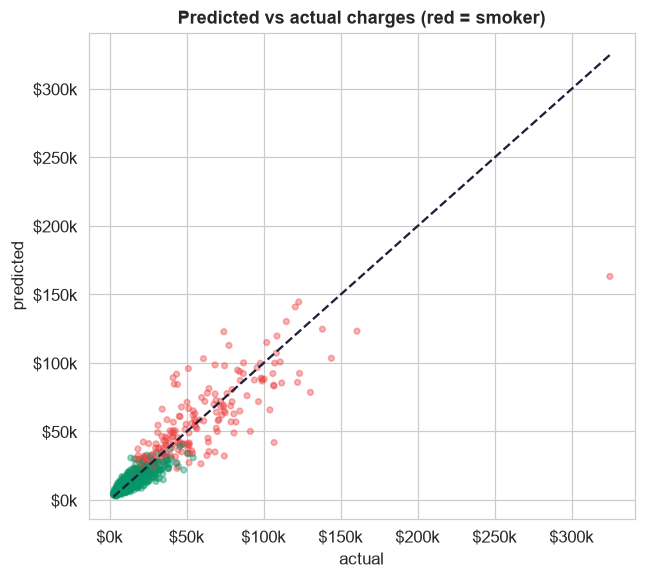

In [13]:
# predicted vs actual, back on the dollar scale
pred = np.exp(ols.predict(Xs))
fig, ax = plt.subplots(figsize=(6,5.4))
colors = [RED if s==1 else EM for s in df.smoker]
ax.scatter(df.charges, pred, s=14, c=colors, alpha=0.4)
lims=[df.charges.min(), df.charges.max()]; ax.plot(lims, lims, ls='--', color=INK)
ax.set(title='Predicted vs actual charges (red = smoker)', xlabel='actual', ylabel='predicted')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k')); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'${v/1000:.0f}k'))
plt.tight_layout(); plt.show()

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 10 &#183; INTERPRET THE RESULTS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Rank the cost drivers</div>
<div style="color:#4a5578;margin-top:6px">Standardized coefficients compare effects on one scale.</div>
</div>

In [14]:
kept = coef[coef.abs()>1e-6].reindex(coef.abs().sort_values(ascending=False).index)
print('Cost drivers, strongest first (standardized effect on log-charges):')
for f, v in kept.head(6).items(): print(f'  {f:16s} {v:+.3f}')
print(f"\nSmoking multiplies charges by roughly e^(raw smoker coef). Its standardized effect ({kept['smoker']:.2f}) dwarfs the rest.")

Cost drivers, strongest first (standardized effect on log-charges):
  smoker           +0.571
  age              +0.417
  blood_pressure   +0.139
  cholesterol      +0.117
  bmi              +0.109
  children         +0.068

Smoking multiplies charges by roughly e^(raw smoker coef). Its standardized effect (0.57) dwarfs the rest.


**What the model says.** **Smoking is the dominant cost driver by a wide margin**, followed by **age**, then **blood pressure**, **cholesterol**, and **BMI**. Income, diet score, and the noise features carry no weight. In plain terms: the biggest, most actionable lever on medical cost is smoking, and the body-size signal is fully captured by BMI alone, no need for height and weight too.

**Actionable:** a smoking-cessation program targets the single largest cost driver; blood pressure and cholesterol point to preventive-care opportunities; and the insurer can price on a short, non-redundant feature set with no loss of accuracy.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 11 &#183; DEPLOY THE MODEL</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Pricing and prevention, responsibly</div>
<div style="color:#4a5578;margin-top:6px">Score patients, and watch for fairness.</div>
</div>

- **Persist** the scaler + lasso as one pipeline (`joblib`), so raw patient data is standardized and scored identically.
- **Score** new applicants for expected cost, always returning a range, and refresh premiums on a schedule.
- **Target prevention**: rank members by the modifiable drivers (smoking, blood pressure, cholesterol) for outreach.
- **Monitor and retrain** as medical costs inflate and the population changes.
- **Fairness first**: a cost model must be checked so it does not proxy protected attributes, and used within legal and ethical limits on what may drive premiums. Regularization aids transparency by keeping the model short and explainable.

<div style="background:#f0fdf4;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#047857;letter-spacing:1px">STEP 12 &#183; THE PLAIN-ENGLISH WRITE-UP</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">For a non-statistician</div>
<div style="color:#4a5578;margin-top:6px">No jargon.</div>
</div>

**What we did.** We took an insurance file with 15 fields per patient, cleaned it (fixed duplicates and inconsistent labels, rebuilt a few missing BMI values from height and weight, standardized the charge amounts), and built a formula that estimates a patient's yearly medical cost, letting the method decide which fields actually matter.

**How good is it?** It explains about **87%** of the differences in cost between patients and holds up on patients it has not seen.

**What drives cost, in order:** **smoking** (by far the biggest), then **age**, **blood pressure**, **cholesterol**, and **body-mass index**. Several fields, income, diet score, and two junk columns, added nothing and were automatically dropped; so were height and weight, because BMI already captures body size.

**Why that dropping matters.** Three of the fields (height, weight, BMI) measured the same thing, which normally makes a model unstable. The method (a 'lasso') sorted this out on its own, keeping one and discarding the rest, and it did the same for the useless fields, leaving a short, trustworthy formula.

**Bottom line: smoking is the number-one cost driver by a wide margin**, and a lean model built on a handful of health measures predicts cost as well as one using everything.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>